# Random Forest Project


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")

## Get the Data

In [5]:
loans = pd.read_csv("loan_data.csv")
print(loans.info())
loans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB
None


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [6]:
loans.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


## Exploratory Data Analysis

**FICO distributions by credit.policy**

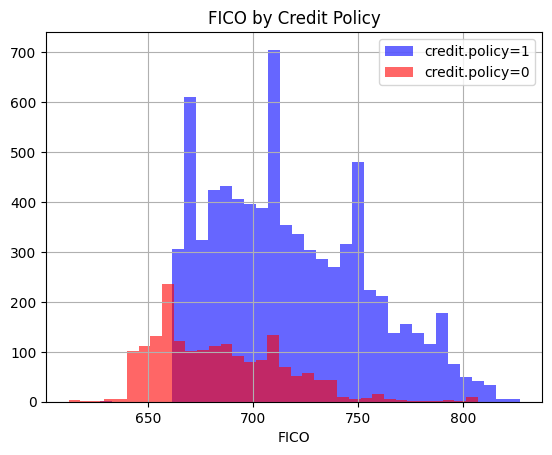

In [7]:
loans[loans["credit.policy"]==1]["fico"].hist(bins=35, color="blue", alpha=0.6, label="credit.policy=1")
loans[loans["credit.policy"]==0]["fico"].hist(bins=35, color="red",  alpha=0.6, label="credit.policy=0")
plt.legend(); plt.xlabel("FICO"); plt.title("FICO by Credit Policy"); plt.show()

**FICO distributions by not.fully.paid**

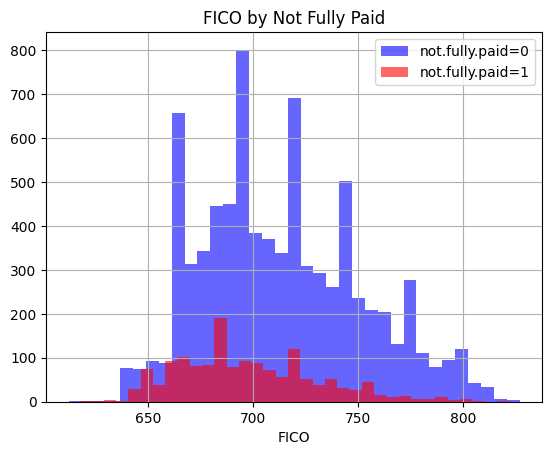

In [8]:
loans[loans["not.fully.paid"]==0]["fico"].hist(bins=35, color="blue", alpha=0.6, label="not.fully.paid=0")
loans[loans["not.fully.paid"]==1]["fico"].hist(bins=35, color="red",  alpha=0.6, label="not.fully.paid=1")
plt.legend(); plt.xlabel("FICO"); plt.title("FICO by Not Fully Paid"); plt.show()

**Countplot: Loan purpose coloured by not.fully.paid**

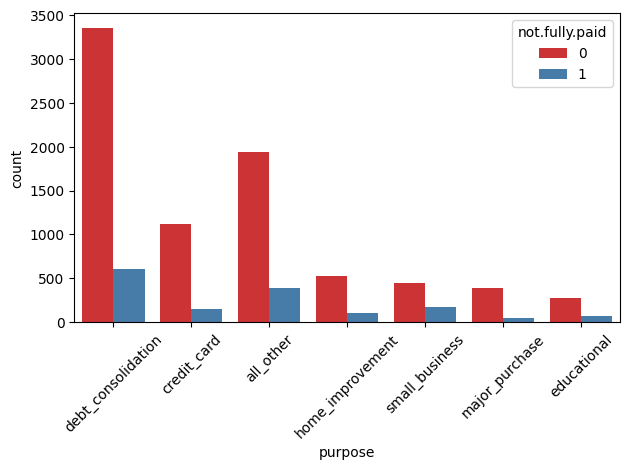

In [9]:
sns.countplot(data=loans, x="purpose", hue="not.fully.paid", palette="Set1")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

**Jointplot: FICO vs Interest Rate**

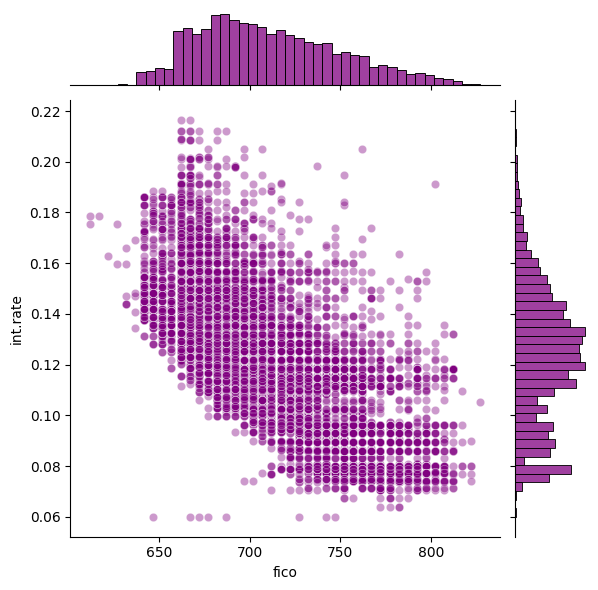

In [10]:
sns.jointplot(data=loans, x="fico", y="int.rate", color="purple", alpha=0.4)

**lmplot: trend by not.fully.paid and credit.policy**

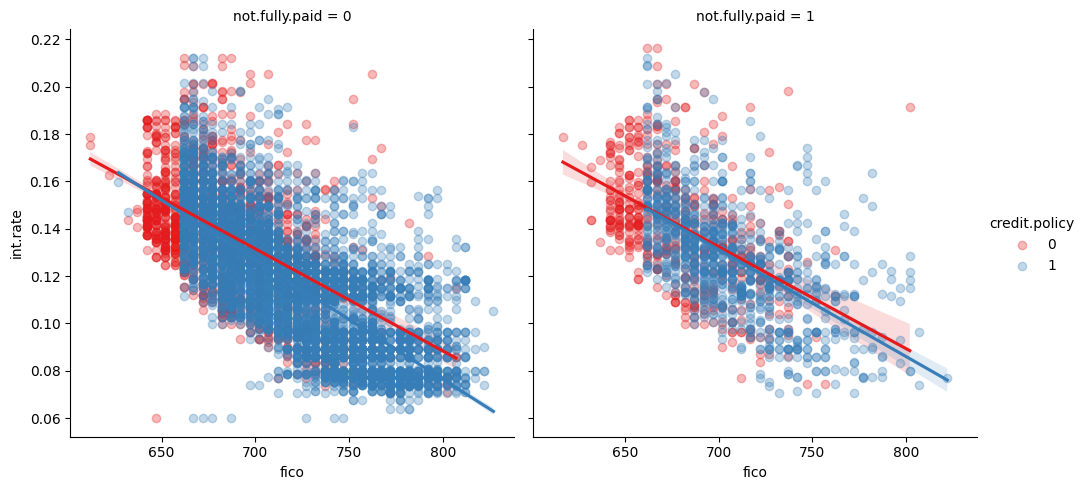

In [11]:
sns.lmplot(data=loans, x="fico", y="int.rate", col="not.fully.paid", hue="credit.policy", palette="Set1", scatter_kws={"alpha":0.3})

## Setting Up the Data
### Categorical Features

In [13]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [14]:
cat_feats = ["purpose"]
final_data = pd.get_dummies(loans, columns=cat_feats, drop_first=True)
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   credit.policy               9578 non-null   int64  
 1   int.rate                    9578 non-null   float64
 2   installment                 9578 non-null   float64
 3   log.annual.inc              9578 non-null   float64
 4   dti                         9578 non-null   float64
 5   fico                        9578 non-null   int64  
 6   days.with.cr.line           9578 non-null   float64
 7   revol.bal                   9578 non-null   int64  
 8   revol.util                  9578 non-null   float64
 9   inq.last.6mths              9578 non-null   int64  
 10  delinq.2yrs                 9578 non-null   int64  
 11  pub.rec                     9578 non-null   int64  
 12  not.fully.paid              9578 non-null   int64  
 13  purpose_credit_card         9578 

### Train / Test Split

In [15]:
from sklearn.model_selection import train_test_split
X = final_data.drop("not.fully.paid", axis=1)
y = final_data["not.fully.paid"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

## Decision Tree Model

In [16]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

### Predictions & Evaluation — Decision Tree

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
dt_preds = dtree.predict(X_test)
print(classification_report(y_test, dt_preds))
print(confusion_matrix(y_test, dt_preds))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      2431
           1       0.18      0.21      0.20       443

    accuracy                           0.73      2874
   macro avg       0.52      0.52      0.52      2874
weighted avg       0.75      0.73      0.74      2874

[[2005  426]
 [ 348   95]]


## Random Forest Model

In [18]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=200, random_state=101)
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=101)

### Predictions & Evaluation — Random Forest

In [19]:
rf_preds = rfc.predict(X_test)
print(classification_report(y_test, rf_preds))
print(confusion_matrix(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.45      0.02      0.04       443

    accuracy                           0.85      2874
   macro avg       0.65      0.51      0.48      2874
weighted avg       0.79      0.85      0.78      2874

[[2419   12]
 [ 433   10]]


### Which model performed better?

**Random Forest** has higher overall accuracy (85% vs 73%) and is far better at correctly predicting loans that were repaid (precision 0.85, recall 1.00 for class 0). However it almost entirely misses the minority class (not.fully.paid=1), with a recall of only 0.02 vs the Decision Tree's 0.23.

### Feature Importances

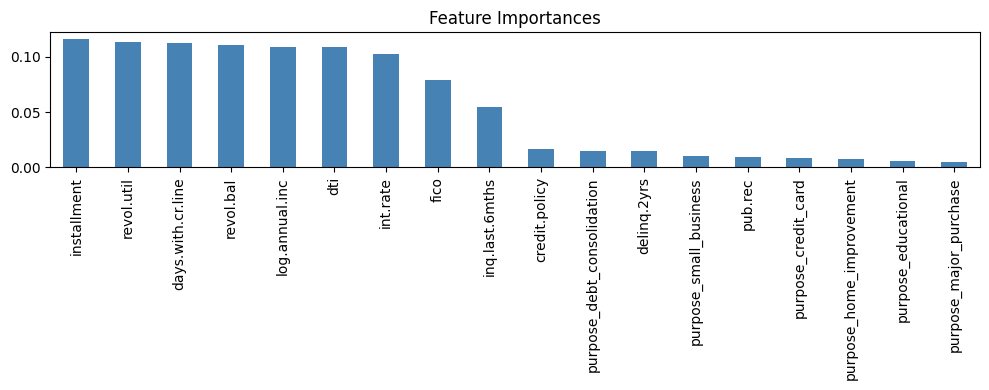

In [20]:
feat_imp = pd.Series(rfc.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind="bar", figsize=(10,4), color="steelblue")
plt.title("Feature Importances"); plt.tight_layout(); plt.show()